   horizon_months   period  backlog_forecast
0               1  2026-01       7245416.195
1               3  2026-03       7252531.895
2               6  2026-06       7252531.895


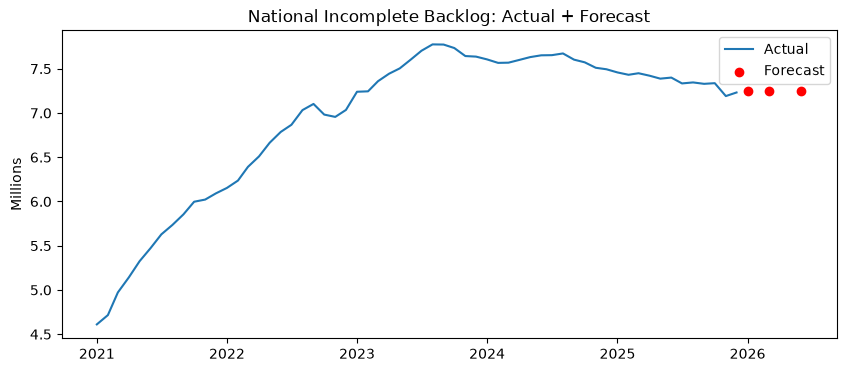

,period_yyyymm,provider_org_name,treatment_function_name,backlog,pct_within_18,gap_vs_92,pct_delta,over_52,risk_score
220318,2025-12,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,Oral Surgery Service,6534.0,21.778390,70.221610,-4.098866,681.0,82.718736
219469,2025-12,THE ROYAL WOLVERHAMPTON NHS TRUST,General Surgery Service,3753.0,30.242473,61.757527,-9.208102,240.0,78.833938
219472,2025-12,THE ROYAL WOLVERHAMPTON NHS TRUST,Ear Nose and Throat Service,5280.0,34.696970,57.303030,-12.018920,252.0,77.516531
219854,2025-12,THE PRINCESS ALEXANDRA HOSPITAL NHS TRUST,Ear Nose and Throat Service,3055.0,27.757774,64.242226,-4.131560,316.0,76.045434
219474,2025-12,THE ROYAL WOLVERHAMPTON NHS TRUST,Oral Surgery Service,4018.0,27.501244,64.498756,-2.907157,290.0,75.339431
220315,2025-12,UNIVERSITY HOSPITALS OF LEICESTER NHS TRUST,Trauma and Orthopaedic Service,9497.0,28.977572,63.022428,0.029930,732.0,71.778139
218515,2025-12,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,Oral Surgery Service,6805.0,31.476855,60.523145,-2.610050,1309.0,71.570299
218569,2025-12,THE HILLINGDON HOSPITALS NHS FOUNDATION TRUST,Ear Nose and Throat Service,3844.0,28.563996,63.436004,9.118765,316.0,71.327211
218513,2025-12,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,Ear Nose and Throat Service,16004.0,35.703574,56.296426,-1.914041,1210.0,67.465030
218512,2025-12,MID AND SOUTH ESSEX NHS FOUNDATION TRUST,Trauma and Orthopaedic Service,19124.0,35.970508,56.029492,-0.799106,3575.0,66.253417


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path("..").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from src.features import load_national_series, load_trust_specialty_monthly
from src.models.forecast import forecast_national_backlog, breach_risk_table

national = load_national_series()
ts = load_trust_specialty_monthly()

# National forecast
fc = forecast_national_backlog(national, horizons=(1, 3, 6))
print(fc)

plt.figure(figsize=(10, 4))
plt.plot(national["period"], national["backlog"] / 1e6, label="Actual")
plt.scatter(
    pd.to_datetime(fc["period"] + "-01"),
    fc["backlog_forecast"] / 1e6,
    color="red",
    label="Forecast",
)
plt.title("National Incomplete Backlog: Actual + Forecast")
plt.ylabel("Millions")
plt.legend()
plt.show()

# Breach risk ranking
risk = breach_risk_table(ts, min_backlog=3000)
display(risk.head(15))